# Figure 2E (revision). Novel genome similarity via kmer-db + lz-ani

Align assembled HQ/HC viruses (post mining-cutoff samples) to **UHGV unique**, **VIRE unique HQ**, **metaVR unique HQ**, and **UHVDB unique** sequences.

**Method** (matches `toolkit2/modules/local/kmerdb_lzani_csvtk`):
1. `kmer-db build -k 25 -f 0.2` on each reference
2. `kmer-db new2all` with `-min num-kmers:1` and `-min ani-shorter:0.7`
3. `lz-ani all2all` restricted to those pairs (`--flt-kmerdb ... 0.7`)

**Plot:** best-hit global ANI (`ani × qcov × 100`); viruses with no pair ≥0.7 → 0.

Heavy steps live under `figure_2e_lzani/` and submit via Slurm. Do **not** re-run assembly from the original `figure_2e.ipynb`.


## 0. Paths and environment

Tools:
- `kmer-db` / `lz-ani` / `csvtk`: micromamba env `vclust`
- `seqkit`: micromamba env `lgonsa`
- converter: `toolkit2/bin/kmerdb_to_lzani.py`

Intermediates: `/gscratch/scrubbed/carsonjm/2026.09.30-figure2e-lzani`


In [2]:
from pathlib import Path

BASE = Path("/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB")
FIG2 = BASE / "uhvdb-manuscript/figure_2"
WORKDIR = FIG2 / "figure_2e_lzani"
REFS = WORKDIR / "refs"
ALIGNMENTS = WORKDIR / "alignments"
PLOTS = WORKDIR / "plots"
LOGS = WORKDIR / "logs"
SBATCH = WORKDIR / "sbatch"
SCRIPTS = WORKDIR / "scripts"

QUERY = FIG2 / "figure2e_results/2026-04-01_outputs/hcfilter/new_hq_hc_viruses.fna.gz"
QUERY_IDS = FIG2 / "hq_hc_new_viruses.ids.txt"
SEQHASHER = BASE / "uhvdb-manuscript/figure_1/figure_1b_revision/data/seqhasher_chunks"
UHVDB_UNIQUE = BASE / "uhvdb-manuscript-update/figure_1/uhvdb_v6_release/uhvdb_unique_reps.fna.gz"

VCLUST_BIN = Path("/mmfs1/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/vclust/bin")
LGONSA_BIN = Path("/mmfs1/gscratch/pedslabs_hoffman/carsonjm/micromamba_envs/envs/lgonsa/bin")
KMERDB_TO_LZANI = BASE / "toolkit2/bin/kmerdb_to_lzani.py"

for d in (REFS, ALIGNMENTS, PLOTS, LOGS, SBATCH, SCRIPTS):
    d.mkdir(parents=True, exist_ok=True)

uhvdb_link = REFS / "uhvdb_unique.fna.gz"
if not uhvdb_link.exists():
    uhvdb_link.symlink_to(UHVDB_UNIQUE)

print("WORKDIR:", WORKDIR)
print("QUERY exists:", QUERY.exists(), QUERY)
print("UHVDB unique:", uhvdb_link.resolve())
print("seqhasher DBs:", sorted(p.name for p in SEQHASHER.iterdir() if p.is_dir()))


WORKDIR: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_2/figure_2e_lzani
QUERY exists: True /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_2/figure2e_results/2026-04-01_outputs/hcfilter/new_hq_hc_viruses.fna.gz
UHVDB unique: /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript-update/figure_1/uhvdb_v6_release/uhvdb_unique_reps.fna.gz
seqhasher DBs: ['metavr', 'uhgv', 'vire']


## 1. Build unique reference FASTAs (UHGV / VIRE / metaVR)

1. From figure 1b `seqhasher` chunks, keep **one sequence ID per unique hash**
2. `seqkit grep --pattern-file` those IDs from the HQ FASTA

UHVDB unique is already linked (`uhvdb_v6_release/uhvdb_unique_reps.fna.gz`).

Submit extract jobs below (or use `sbatch/submit_all.sh` to chain extract → align).


In [ ]:
%%bash
# Submit unique-FASTA extraction for UHGV, VIRE, metaVR
FIG2E=/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_2/figure_2e_lzani
LOGS="$FIG2E/logs"

for db in uhgv vire metavr; do
  sbatch \
    --job-name="f2e_uniq_${db}" \
    --output="$LOGS/extract_${db}.%j.out" \
    --error="$LOGS/extract_${db}.%j.err" \
    --export=ALL,DB_NAME="$db" \
    "$FIG2E/sbatch/extract_unique.sbatch"
done

squeue -u "$USER" -n f2e_uniq_uhgv,f2e_uniq_vire,f2e_uniq_metavr 2>/dev/null || true


In [ ]:
# Check unique FASTA status
refs = {
    "UHGV": REFS / "uhgv_unique.fna.gz",
    "VIRE": REFS / "vire_unique_hq.fna.gz",
    "metaVR": REFS / "metavr_unique_hq.fna.gz",
    "UHVDB": REFS / "uhvdb_unique.fna.gz",
}
for name, path in refs.items():
    if path.exists() and path.stat().st_size > 0:
        print(f"{name:8s} OK  {path.stat().st_size/1e9:.2f} GB  {path}")
    else:
        print(f"{name:8s} MISSING  {path}")


## 2. Align query → each database (kmer-db + lz-ani)

Parameters:
- `-k 25 -f 0.2` (20% of kmers)
- `-min num-kmers:1`, `ani-shorter` / distance / `--flt-kmerdb` at `0.7`
- lz-ani only aligns pairs passing the kmer-db 0.7 prefilter

`submit_all.sh` extracts missing unique FASTAs then submits the four alignment jobs (with Slurm dependencies).


In [ ]:
%%bash
# Full pipeline: extract uniques (if needed) then align all four DBs
bash /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_2/figure_2e_lzani/sbatch/submit_all.sh
squeue -u "$USER" | grep -E 'f2e_|JOBID' || true


In [ ]:
%%bash
# Optional: align a single DB after its unique FASTA is ready (UHGV example)
# FIG2E=.../figure_2e_lzani
# sbatch --job-name=f2e_aln_uhgv \
#   --output="$FIG2E/logs/align_uhgv.%j.out" \
#   --error="$FIG2E/logs/align_uhgv.%j.err" \
#   --export=ALL,DB_NAME=uhgv,REF_FASTA="$FIG2E/refs/uhgv_unique.fna.gz" \
#   "$FIG2E/sbatch/align_kmerdb_lzani.sbatch"
echo "Uncomment the sbatch block above to submit a single alignment job." 


In [ ]:
# Check alignment outputs
for db in ["uhgv", "vire", "metavr", "uhvdb"]:
    p = ALIGNMENTS / f"{db}.lzani.tsv.gz"
    if p.exists() and p.stat().st_size > 0:
        print(f"{db:8s} OK  {p.stat().st_size/1e6:.1f} MB  {p}")
    else:
        print(f"{db:8s} MISSING  {p}")


## 3. Map queries to body site and plot best-hit global ANI

Reuse samplesheets from the original figure 2e workflow. Oral samples are labeled `airways` → **Airways** on the plot.


In [3]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

gut = pl.read_csv(FIG2 / "gut_samplesheet.csv").with_columns(pl.lit("gut").alias("body_site"))
oral = pl.read_csv(FIG2 / "oral_samplesheet.csv").with_columns(pl.lit("airways").alias("body_site"))
skin = pl.read_csv(FIG2 / "skin_samplesheet.csv").with_columns(pl.lit("skin").alias("body_site"))
uro = pl.read_csv(FIG2 / "urogenital_samplesheet.csv").with_columns(pl.lit("urogenital").alias("body_site"))
combined_samplesheet = pl.concat([gut, oral, skin, uro])

seq2site = (
    pl.read_csv(QUERY_IDS, has_header=False)
    .rename({"column_1": "qname"})
    .with_columns([
        pl.col("qname").str.split("_k").list.first().str.replace(">", "").alias("acc"),
        pl.col("qname").str.replace(">", "").str.split(" ").list.first().alias("qname"),
    ])
    .join(combined_samplesheet.select(["acc", "body_site"]), on="acc", how="inner")
)

print(seq2site.group_by("body_site").len().sort("body_site"))
print("n queries with body site:", seq2site.height)


shape: (4, 2)
┌────────────┬──────┐
│ body_site  ┆ len  │
│ ---        ┆ ---  │
│ str        ┆ u32  │
╞════════════╪══════╡
│ airways    ┆ 756  │
│ gut        ┆ 2176 │
│ skin       ┆ 271  │
│ urogenital ┆ 242  │
└────────────┴──────┘
n queries with body site: 3445


In [4]:
def load_best_hits(lzani_path: Path, database: str, seq2site: pl.DataFrame) -> pl.DataFrame:
    """Best-hit global ANI per query; missing hits filled with 0."""
    hits = pl.read_csv(lzani_path, separator="\t")
    query_ids = set(seq2site["qname"].to_list())
    hits = hits.filter(pl.col("query").is_in(query_ids))
    best = (
        hits
        .with_columns((pl.col("ani") * pl.col("qcov") * 100).alias("qani"))
        .sort("qani", descending=True)
        .group_by("query", maintain_order=True)
        .first()
        .rename({"query": "qname"})
    )
    out = (
        seq2site
        .join(best.select(["qname", "reference", "ani", "qcov", "rcov", "qani"]), on="qname", how="left")
        .with_columns([
            pl.col("qani").fill_null(0.0),
            pl.lit(database).alias("Database"),
        ])
    )
    return out


db_files = {
    "UHGV": ALIGNMENTS / "uhgv.lzani.tsv.gz",
    "VIRE": ALIGNMENTS / "vire.lzani.tsv.gz",
    "metaVR": ALIGNMENTS / "metavr.lzani.tsv.gz",
    "UHVDB": ALIGNMENTS / "uhvdb.lzani.tsv.gz",
}

missing = [k for k, p in db_files.items() if not p.exists() or p.stat().st_size == 0]
if missing:
    raise FileNotFoundError(
        f"Alignment outputs missing for: {missing}. "
        "Wait for Slurm jobs to finish, then re-run this cell."
    )

best_hits = pl.concat([load_best_hits(path, name, seq2site) for name, path in db_files.items()])
best_hits = best_hits.with_columns(
    pl.col("body_site")
    .str.replace("airways", "Airways")
    .str.replace("gut", "Gut")
    .str.replace("skin", "Skin")
    .str.replace("urogenital", "Urogenital")
)

best_hits.write_csv(WORKDIR / "best_hits_global_ani.tsv", separator="\t")
print(
    best_hits.group_by(["Database", "body_site"])
    .agg(pl.col("qani").mean().alias("mean_qani"))
    .sort(["Database", "body_site"])
)
best_hits.head()


shape: (16, 3)
┌──────────┬────────────┬───────────┐
│ Database ┆ body_site  ┆ mean_qani │
│ ---      ┆ ---        ┆ ---       │
│ str      ┆ str        ┆ f64       │
╞══════════╪════════════╪═══════════╡
│ UHGV     ┆ Airways    ┆ 57.180231 │
│ UHGV     ┆ Gut        ┆ 83.338382 │
│ UHGV     ┆ Skin       ┆ 40.081945 │
│ UHGV     ┆ Urogenital ┆ 41.788469 │
│ UHVDB    ┆ Airways    ┆ 89.285189 │
│ …        ┆ …          ┆ …         │
│ VIRE     ┆ Urogenital ┆ 71.326653 │
│ metaVR   ┆ Airways    ┆ 75.509822 │
│ metaVR   ┆ Gut        ┆ 85.607467 │
│ metaVR   ┆ Skin       ┆ 63.502838 │
│ metaVR   ┆ Urogenital ┆ 64.514887 │
└──────────┴────────────┴───────────┘


qname,acc,body_site,reference,ani,qcov,rcov,qani,Database
str,str,str,str,f64,f64,f64,f64,str
"""DRR576658_k251_2015""","""DRR576658""","""Gut""","""UHGV-2008457""",0.991311,0.965527,0.978318,95.713754,"""UHGV"""
"""DRR576658_k251_3293""","""DRR576658""","""Gut""","""UHGV-0131897""",0.898339,0.592327,0.619502,53.211044,"""UHGV"""
"""DRR576658_k251_62816""","""DRR576658""","""Gut""","""UHGV-1538249""",0.999484,1.0,0.932322,99.9484,"""UHGV"""
"""DRR576658_k251_59557|provirus_…","""DRR576658""","""Gut""","""UHGV-1973151""",0.767315,0.468577,0.406598,35.954616,"""UHGV"""
"""DRR576658_k251_62769|provirus_…","""DRR576658""","""Gut""","""UHGV-2141223""",0.972131,0.739116,0.709614,71.851758,"""UHGV"""


In [5]:
# Species-level hit rates (optional manuscript stats): ani>=0.95 and (qcov|rcov)>=0.85
for database, path in db_files.items():
    hits = pl.read_csv(path, separator="\t")
    query_ids = set(seq2site["qname"].to_list())
    hits = hits.filter(pl.col("query").is_in(query_ids))
    hit_ids = set(
        hits.filter(
            (pl.col("ani") >= 0.95)
            & ((pl.col("qcov") >= 0.85) | (pl.col("rcov") >= 0.85))
        )["query"].to_list()
    )
    print(f"=== {database} species-level ===")
    for site in ["gut", "airways", "skin", "urogenital"]:
        site_q = seq2site.filter(pl.col("body_site") == site)["qname"].to_list()
        total = len(site_q)
        n_hit = sum(1 for q in site_q if q in hit_ids)
        prop = n_hit / total if total else float("nan")
        print(f"  {site:12s} {n_hit}/{total} = {prop:.4f}")
    print()


=== UHGV species-level ===
  gut          1491/2176 = 0.6852
  airways      108/756 = 0.1429
  skin         37/271 = 0.1365
  urogenital   56/242 = 0.2314

=== VIRE species-level ===
  gut          1583/2176 = 0.7275
  airways      340/756 = 0.4497
  skin         140/271 = 0.5166
  urogenital   91/242 = 0.3760

=== metaVR species-level ===
  gut          1559/2176 = 0.7165
  airways      223/756 = 0.2950
  skin         94/271 = 0.3469
  urogenital   91/242 = 0.3760

=== UHVDB species-level ===
  gut          1757/2176 = 0.8074
  airways      465/756 = 0.6151
  skin         180/271 = 0.6642
  urogenital   190/242 = 0.7851



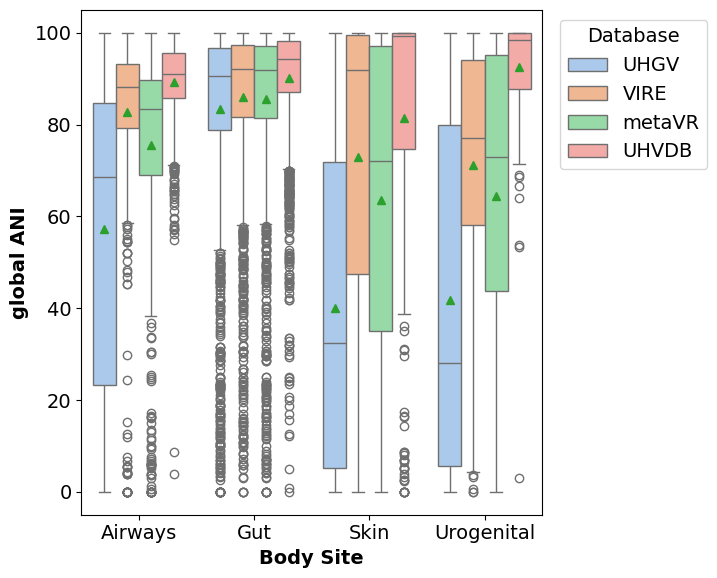

saved /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/uhvdb-manuscript/figure_2/figure_2e_lzani/plots/figure_2e_global_ani_by_body_site.png
Mean % identity for Airways samples to UHGV: 57.18023091921157
Mean % identity for Airways samples to VIRE: 82.68994186226777
Mean % identity for Airways samples to metaVR: 75.50982237919784
Mean % identity for Airways samples to UHVDB: 89.28518882175511
Mean % identity for Gut samples to UHGV: 83.33838195081786
Mean % identity for Gut samples to VIRE: 85.94968448052535
Mean % identity for Gut samples to metaVR: 85.60746742052001
Mean % identity for Gut samples to UHVDB: 90.1490556324402
Mean % identity for Skin samples to UHGV: 40.08194489210811
Mean % identity for Skin samples to VIRE: 72.91959740179404
Mean % identity for Skin samples to metaVR: 63.50283807101581
Mean % identity for Skin samples to UHVDB: 81.48761873525254
Mean % identity for Urogenital samples to UHGV: 41.788468623560846
Mean % identity for Urogenital samples t

In [6]:
sns.reset_orig()
plt.rcParams.update({"font.size": 14})

plot_df = best_hits.to_pandas()
hue_order = ["UHGV", "VIRE", "metaVR", "UHVDB"]
site_order = ["Airways", "Gut", "Skin", "Urogenital"]

plt.figure(figsize=(8, 6))
sns.boxplot(
    x="body_site",
    y="qani",
    hue="Database",
    hue_order=hue_order,
    order=site_order,
    palette="pastel",
    data=plot_df,
    showmeans=True,
)
plt.xlabel("Body Site", fontdict={"fontweight": "bold"})
plt.ylabel("global ANI", fontdict={"fontweight": "bold"})
plt.legend(title="Database", bbox_to_anchor=(1.38, 1), loc="upper right")
plt.tight_layout()

out_png = PLOTS / "figure_2e_global_ani_by_body_site.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
print("saved", out_png)

for body_site in site_order:
    for database in hue_order:
        mean_id = (
            best_hits.filter(
                (pl.col("body_site") == body_site) & (pl.col("Database") == database)
            )
            .select(pl.col("qani").mean())
            .item()
        )
        print(f"Mean % identity for {body_site} samples to {database}: {mean_id}")
